In [6]:
# This notebook can be used to process flight files and generate pickled files of correlator+drone data

In [7]:
## First import general packages for running python analysis:
import os, h5py, datetime,pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
import reduce as rc
gbosite=si.Site('../metadata/GBO_DNS_config.npz')

# Define any channels, etc, and directories for this flight analysis

#config_directory="  "
maindir = '/hirax/DNS_freespace/TONE_july_2025/'
dronedir = maindir+'processed_flight_records/'
cdir = maindir+'TONE_iceboard_files/corr_data/'
gdir = maindir+'TONE_iceboard_files/digital_gains/' 

# define which channels in the data files are useful
crmap = [0,3,4,6,7,8,9]
chnames = ['EW_D5_auto','EW_D5_cr','NS_D5_auto','NS_D5_cr','NS_D8_auto','NS_D8_cr','ref_auto']

# from crmap, which indices are autos, which indices are ref crosses
autos = [0,2,4,6]
crosses = [1,3,5]


# define default 'good' frequency for plotting
f_ind = 304 
freqs = np.arange(800,400,-400./1024)
print(freqs[f_ind])

###################
#### FUNCTIONS ####
###################

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))



681.25


In [8]:
flightpickles = os.listdir(maindir+'flight_pickles/')
print(flightpickles)

['Jul-17th-2025-07-56PM_20250717T234526Z_WVUc52_ver_20251001T121657_concat.pkl', 'Jul-17th-2025-01-51PM_20250717T160156Z_WVUc52_ver_20251001T112245_concat.pkl', 'Jul-17th-2025-04-39PM_20250717T192717Z_WVUc52_ver_20251001T115351_concat.pkl', 'Jul-17th-2025-12-16PM_20250717T160156Z_WVUc52_ver_20250930T171215_concat.pkl']


Loading:  /hirax/DNS_freespace/TONE_july_2025/flight_pickles/Jul-17th-2025-07-56PM_20250717T234526Z_WVUc52_ver_20251001T121657_concat.pkl


<ipython-input-9-243d8368a18f>:12: RuntimeWarning: divide by zero encountered in log10
  c=10*np.log10(abs(flight0.V_cross_bgsub[flight0.inds_on,f_ind,chind])), cmap='gnuplot2')


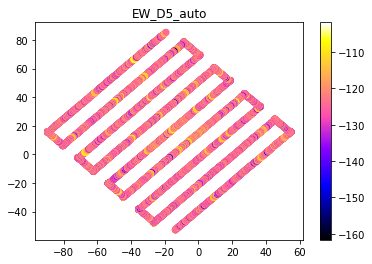

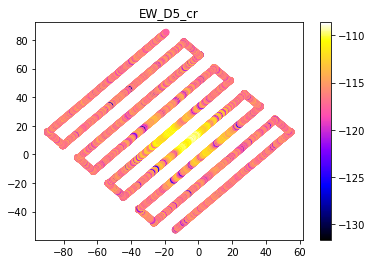

In [9]:
# N pol flights: 0, 2, 3

f=0
radfile = maindir+'flight_pickles/'+flightpickles[f]
print('Loading: ',radfile)
with open(radfile, 'rb') as inp:
    flight0 = pickle.load(inp)


for chind in [0,1]:
    plt.scatter(flight0.drone_xyz_LC_interp[flight0.inds_on,0],flight0.drone_xyz_LC_interp[flight0.inds_on,1],
               c=10*np.log10(abs(flight0.V_cross_bgsub[flight0.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()

(4, 512, 7)
-19.70334734270674 13.172181108631916


<ipython-input-10-d313ca821ea1>:9: RuntimeWarning: divide by zero encountered in log10
  c=10*np.log10(abs(flight0.V_cross_bgsub[flight0.inds_on,f_ind,chind])), cmap='gnuplot2')


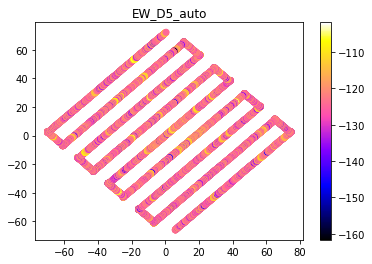

-31.97006619706888 8.996719431796432


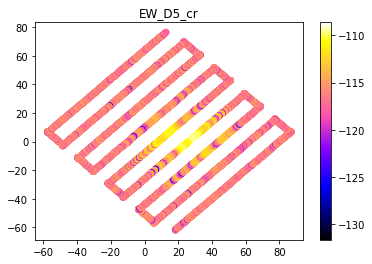

In [10]:
print(flight0.G_popt.shape) # chan, freq, parameter [amp,x0,xsig,y0,ysig,c]

for chind in [0,1]:
    xoff = flight0.G_popt[chind,f_ind, 1]
    yoff = flight0.G_popt[chind,f_ind, 3]
    print(xoff,yoff)
    plt.scatter(flight0.drone_xyz_LC_interp[flight0.inds_on,0]-xoff,
                flight0.drone_xyz_LC_interp[flight0.inds_on,1]-yoff,
               c=10*np.log10(abs(flight0.V_cross_bgsub[flight0.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()


Loading:  /hirax/DNS_freespace/TONE_july_2025/flight_pickles/Jul-17th-2025-04-39PM_20250717T192717Z_WVUc52_ver_20251001T115351_concat.pkl


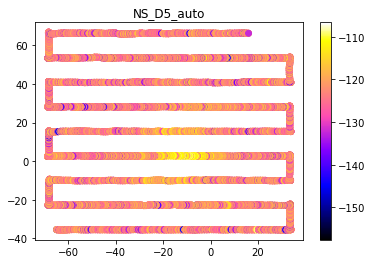

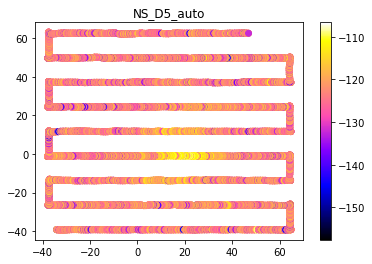

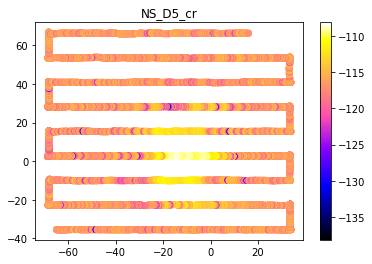

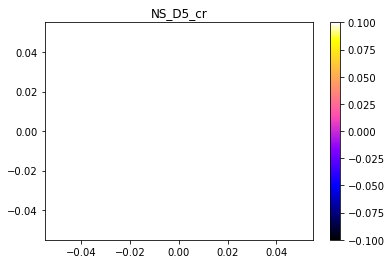

In [11]:
f=2
radfile = maindir+'flight_pickles/'+flightpickles[f]
print('Loading: ',radfile)
with open(radfile, 'rb') as inp:
    flight2 = pickle.load(inp)


for chind in [2,3]:
    plt.scatter(flight2.drone_xyz_LC_interp[flight2.inds_on,0],flight2.drone_xyz_LC_interp[flight2.inds_on,1],
               c=10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()
    
    xoff = 0
    yoff = 0
    
    plt.scatter(flight2.drone_xyz_LC_interp[flight2.inds_on,0]-xoff,
                flight2.drone_xyz_LC_interp[flight2.inds_on,1]-yoff,
               c=10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()

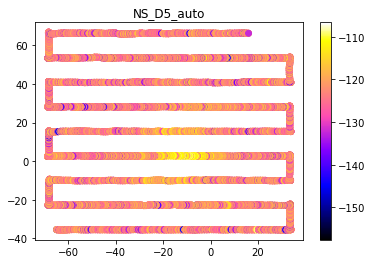

-30.81744301162359 3.704811314583262


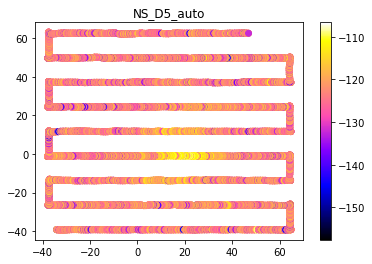

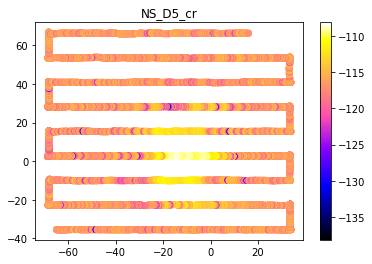

nan nan


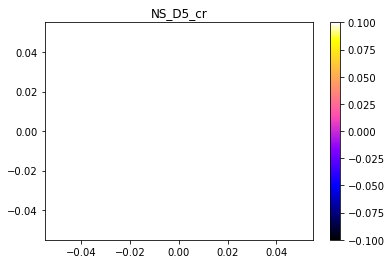

In [12]:
for chind in [2,3]:
    plt.scatter(flight2.drone_xyz_LC_interp[flight2.inds_on,0],flight2.drone_xyz_LC_interp[flight2.inds_on,1],
               c=10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()
    
    xoff = flight2.G_popt[chind,f_ind, 1]
    yoff = flight2.G_popt[chind,f_ind, 3]
    print(xoff,yoff)
    
    plt.scatter(flight2.drone_xyz_LC_interp[flight2.inds_on,0]-xoff,
                flight2.drone_xyz_LC_interp[flight2.inds_on,1]-yoff,
               c=10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()

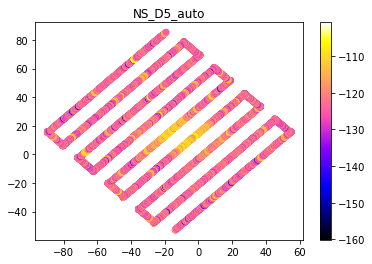

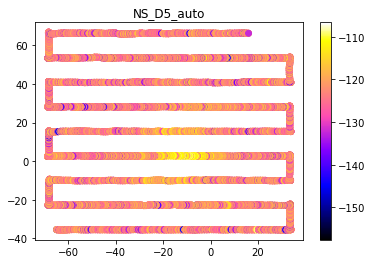

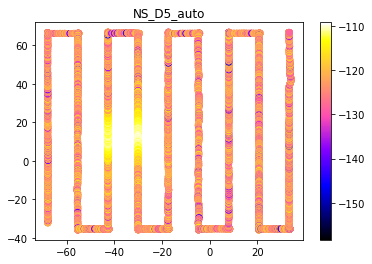

In [20]:
# plot a map of autos
chind = 2

plt.scatter(flight0.drone_xyz_LC_interp[flight0.inds_on,0],flight0.drone_xyz_LC_interp[flight0.inds_on,1],
               c=10*np.log10(abs(flight0.V_cross_bgsub[flight0.inds_on,f_ind,chind])), cmap='gnuplot2')
plt.colorbar()
plt.title(chnames[chind])
plt.show()

plt.scatter(flight2.drone_xyz_LC_interp[flight2.inds_on,0],flight2.drone_xyz_LC_interp[flight2.inds_on,1],
               c=10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_on,f_ind,chind])), cmap='gnuplot2')
plt.colorbar()
plt.title(chnames[chind])
plt.show()

plt.scatter(flight3.drone_xyz_LC_interp[flight3.inds_on,0],flight3.drone_xyz_LC_interp[flight3.inds_on,1],
               c=10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on,f_ind,chind])), cmap='gnuplot2')
plt.colorbar()
plt.title(chnames[chind])
plt.show()

(28672, 1024, 7) (28672, 1024, 7) (28672, 1024, 7)


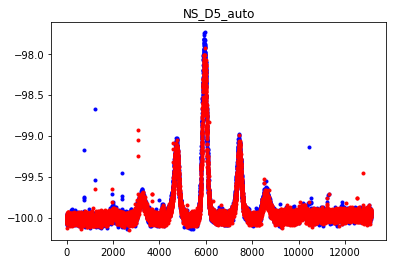

<ipython-input-13-4ba550ca58bc>:15: RuntimeWarning: divide by zero encountered in log10
  plt.plot(10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_off,f_ind,chind])),'r.')


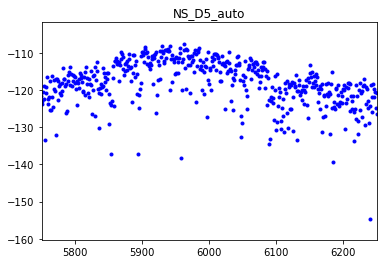

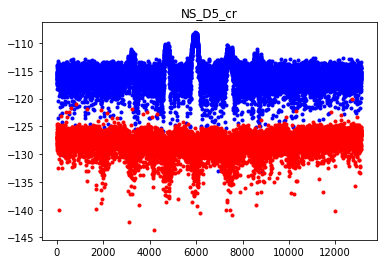

<ipython-input-13-4ba550ca58bc>:15: RuntimeWarning: divide by zero encountered in log10
  plt.plot(10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_off,f_ind,chind])),'r.')


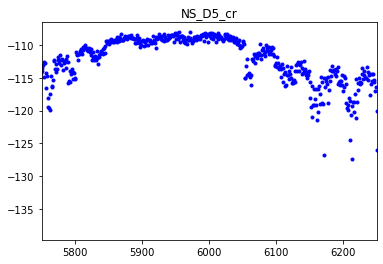

In [13]:
f_ind = 304

print(flight2.V_cross.shape, flight2.V_cross_bg.shape, flight2.V_cross_bgsub.shape)
    
for chind in [2,3]:
    plt.plot(10*np.log10(abs(flight2.V_cross[flight2.inds_on,f_ind,chind])),'b.')
    plt.plot(10*np.log10(abs(flight2.V_cross[flight2.inds_off,f_ind,chind])),'r.')
    plt.title(chnames[chind])
    #plt.xlim(5750,6250)
    plt.show()
    

    
    plt.plot(10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_on,f_ind,chind])),'b.')
    plt.plot(10*np.log10(abs(flight2.V_cross_bgsub[flight2.inds_off,f_ind,chind])),'r.')
    plt.title(chnames[chind])
    plt.xlim(5750,6250)
    plt.show()

Loading:  /hirax/DNS_freespace/TONE_july_2025/flight_pickles/Jul-17th-2025-12-16PM_20250717T160156Z_WVUc52_ver_20250930T171215_concat.pkl


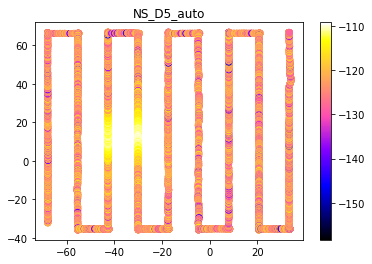

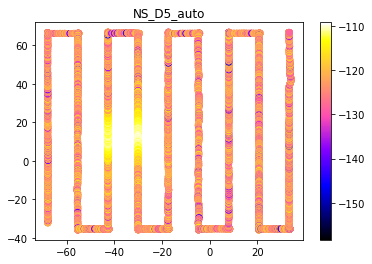

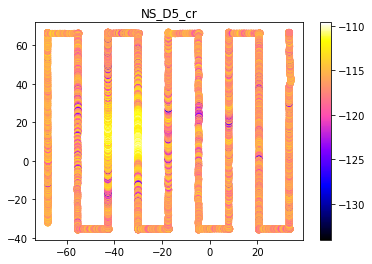

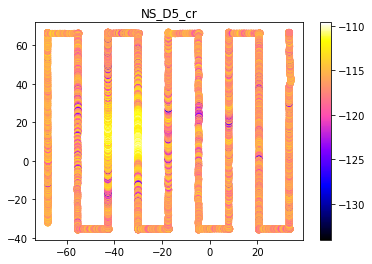

In [14]:

f=3
radfile = maindir+'flight_pickles/'+flightpickles[f]
print('Loading: ',radfile)
with open(radfile, 'rb') as inp:
    flight3 = pickle.load(inp)


for chind in [2,3]:
    achind = 2
    plt.scatter(flight3.drone_xyz_LC_interp[flight3.inds_on,0],flight3.drone_xyz_LC_interp[flight3.inds_on,1],
               c=10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()
    
    xoff = 0
    yoff = 0
    
    plt.scatter(flight3.drone_xyz_LC_interp[flight3.inds_on,0]-xoff,
                flight3.drone_xyz_LC_interp[flight3.inds_on,1]-yoff,
               c=10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()

In [5]:
print(flight3.t_delta_dji)

-13.770000000000016


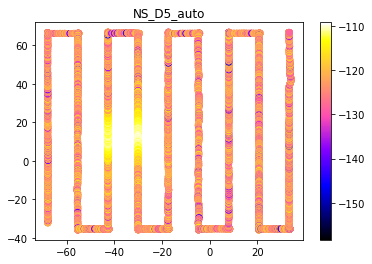

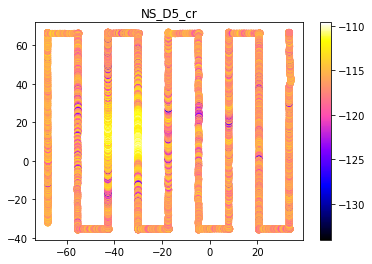

In [45]:
f_ind = 304

for chind in [2,3]:
    achind = 2
    plt.scatter(flight3.drone_xyz_LC_interp[flight3.inds_on,0],flight3.drone_xyz_LC_interp[flight3.inds_on,1],
               c=10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on,f_ind,chind])), cmap='gnuplot2')
    plt.colorbar()
    plt.title(chnames[chind])
    plt.show()
    
    #xoff = flight3.G_popt[achind,f_ind, 1]
    #yoff = flight3.G_popt[achind,f_ind, 3]
    
    #plt.scatter(flight3.drone_xyz_LC_interp[flight3.inds_on,0]-xoff,
    #            flight3.drone_xyz_LC_interp[flight3.inds_on,1]-yoff,
    #           c=10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on,f_ind,chind])), cmap='gnuplot2')
    #plt.colorbar()
    #plt.title(chnames[chind])
    #plt.show()

(29440, 1024, 7) (29440, 1024, 7) (29440, 1024, 7)


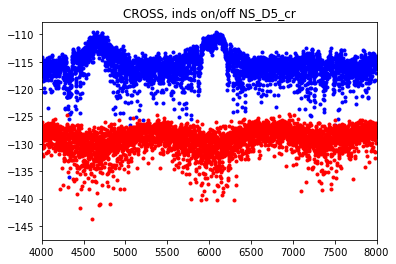

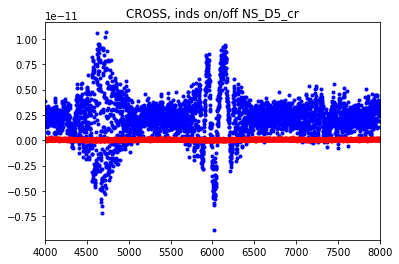

<ipython-input-77-1bc7ec31e8b4>:20: RuntimeWarning: divide by zero encountered in log10
  plt.plot(10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_off,f_ind,chind])),'r.')


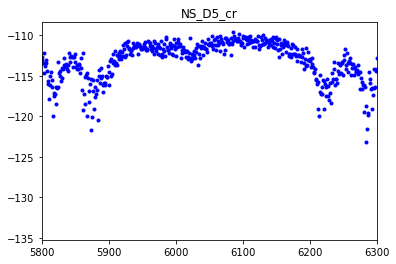

In [77]:
print(flight3.V_cross.shape, flight3.V_cross_bg.shape, flight3.V_cross_bgsub.shape)
    
for chind in [3]:
    plt.plot(10*np.log10(abs(flight3.V_cross[flight3.inds_on,f_ind,chind])),'b.')
    plt.plot(10*np.log10(abs(flight3.V_cross[flight3.inds_off,f_ind,chind])),'r.')
    plt.title('CROSS, inds on/off '+ chnames[chind])
    #plt.xlim(5750,6250)
    plt.xlim(4000,8000)
    plt.show()
    
    plt.plot(flight3.V_cross[flight3.inds_on,f_ind,chind].real,'b.')
    plt.plot(flight3.V_cross[flight3.inds_off,f_ind,chind].real,'r.')
    plt.title('CROSS, inds on/off '+ chnames[chind])
    #plt.xlim(5750,6250)
    plt.xlim(4000,8000)
    plt.show()

    
    plt.plot(10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on,f_ind,chind])),'b.')
    plt.plot(10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_off,f_ind,chind])),'r.')
    plt.title(chnames[chind])
    plt.xlim(5800,6300)
    plt.show()

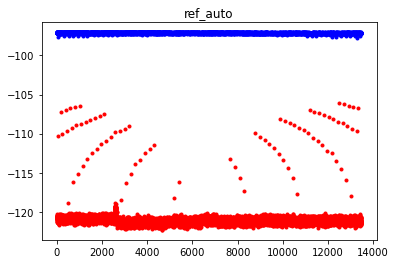

<ipython-input-51-4040a5d15d2f>:11: RuntimeWarning: divide by zero encountered in log10
  plt.plot(10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_off,f_ind,chind])),'r.')


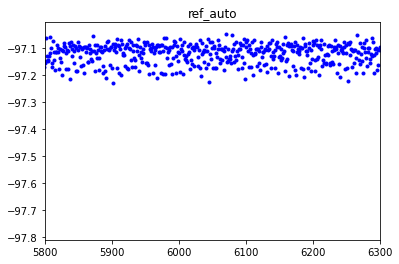

In [51]:
for chind in [6]:
    plt.plot(10*np.log10(abs(flight3.V_cross[flight3.inds_on,f_ind,chind])),'b.')
    plt.plot(10*np.log10(abs(flight3.V_cross[flight3.inds_off,f_ind,chind])),'r.')
    plt.title(chnames[chind])
    #plt.xlim(5750,6250)
    plt.show()
    

    
    plt.plot(10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on,f_ind,chind])),'b.')
    plt.plot(10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_off,f_ind,chind])),'r.')
    plt.title(chnames[chind])
    plt.xlim(5800,6300)
    plt.show()

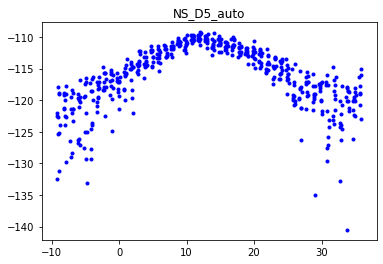

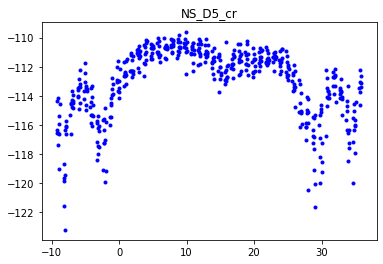

In [52]:
lb = 5800
ub = 6300



for chind in [2,3]:  
    plt.plot(flight3.drone_xyz_LC_interp[flight3.inds_on[lb:ub],1],10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on[lb:ub],f_ind,chind])),'b.')
    plt.title(chnames[chind])
    plt.show()
    
for chind in [2,3]:  
    plt.plot(flight3.drone_xyz_LC_interp[flight3.inds_on[lb:ub],1],10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on[lb:ub],f_ind,chind])),'b.')
    plt.title(chnames[chind])
    plt.show()

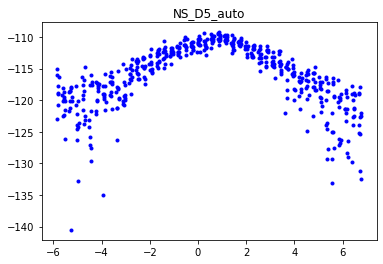

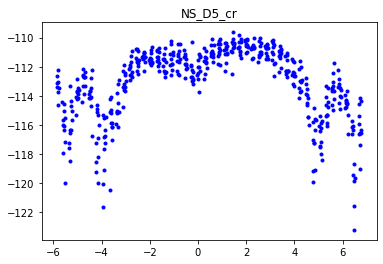

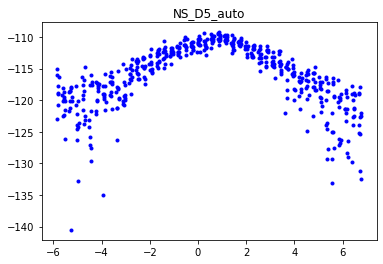

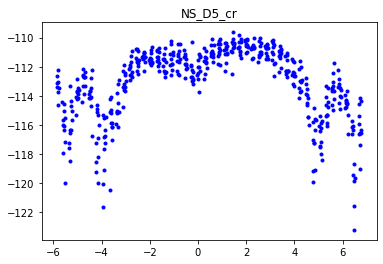

In [71]:
lb = 5800
ub = 6300


angles = np.degrees(np.arctan2(
    flight3.drone_xyz_LC_interp[flight3.inds_on[lb:ub],2],
    (flight3.drone_xyz_LC_interp[flight3.inds_on[lb:ub],1]-15))) - 90

#print(angles)

for chind in [2,3]:  
    plt.plot(angles,10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on[lb:ub],f_ind,chind])),'b.')
    plt.title(chnames[chind])
    plt.show()
    
for chind in [2,3]:  
    plt.plot(angles,10*np.log10(abs(flight3.V_cross_bgsub[flight3.inds_on[lb:ub],f_ind,chind])),'b.')
    plt.title(chnames[chind])
    plt.show()

In [68]:
np.degrees(np.arctan2(203,15))

85.77400182204154